In [17]:
import numpy as np
import cv2 
import matplotlib.pyplot as plt
from scipy.fftpack import fft2, ifft2, fftshift, ifftshift  

In [23]:
image_edge = cv2.imread('edge.png',cv2.IMREAD_GRAYSCALE)
img_smooth = cv2.imread('smooth.JPG',cv2.IMREAD_GRAYSCALE)

creating ILPF function 

In [20]:
def ILPF(image,D0):
    
    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum1 = np.log(np.abs(fshift) + 1)

    row , col = image.shape[0],image.shape[1]
    mask = np.zeros((row,col),dtype=np.uint8)

    for i in range(row):
         for j in range(col):
            if((i-row/2)**2+(j-col/2)**2)< D0**2:
                mask[i,j]=1

    filtered_image  = fshift * mask 
    img_back = np.fft.ifft2(np.fft.ifftshift(filtered_image))
    img_back = np.abs(img_back)
    plt.figure(figsize=(10,5))
    
    plt.subplot(121),plt.imshow(mask,cmap='gray')   
    plt.subplot(122),plt.imshow(np.abs(img_back),cmap='gray')          



در اینجا تابعی نوشتیم که فرکانس های بالا را قطع میکند و این یعنی تصویر ما را به یک تصویر نرم تبدیل میکند 

وقتی شعاع را برابر 25 قرار بدهیم فرکانس ها با خشونت بیشتر قطع و حذف میگردند و تصویر بسیار نرم و تاری خواهیم داشت . 

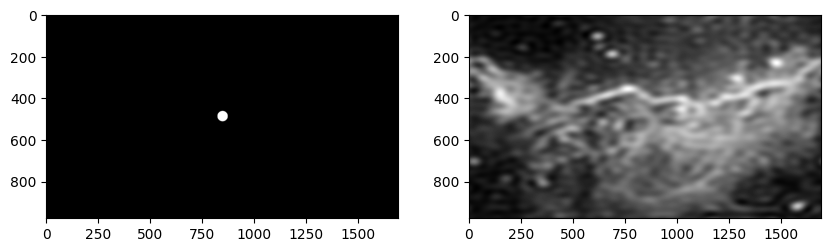

In [21]:
ILPF(img_smooth,25)

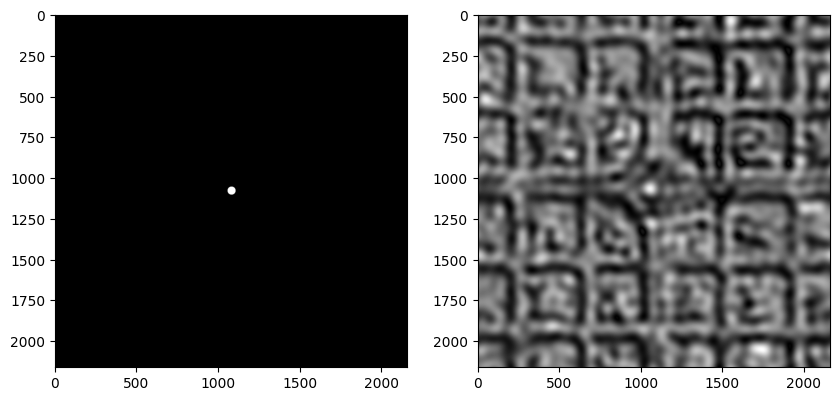

In [24]:
ILPF(image_edge,25)

چنانچه شعاع را برابر 80 فرض کنیم میتوان تصویر اندکی شارپ تر دریافت کرد به دلیل عبور فرکانس های بالای بیشتر نسبت به حالت قبل 

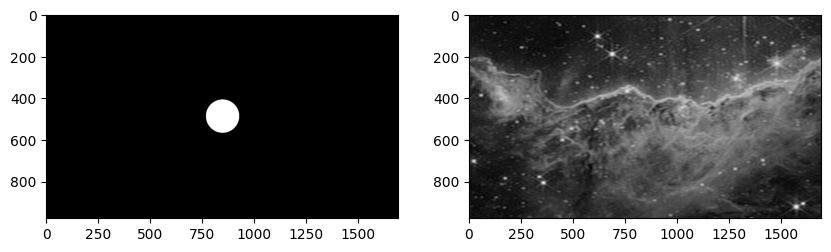

In [25]:
ILPF(img_smooth,80)

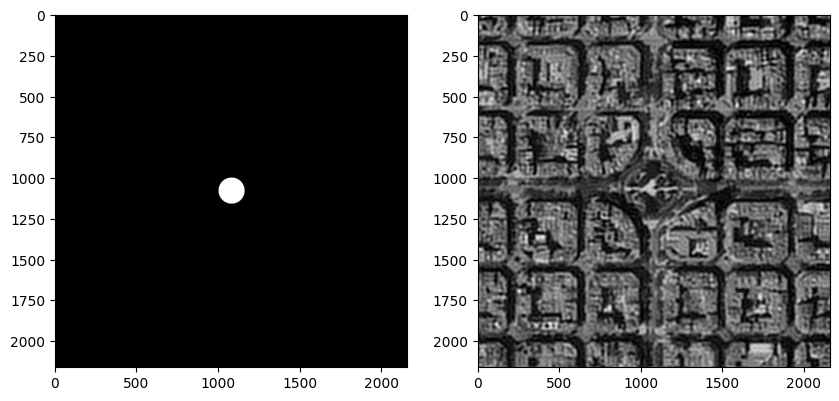

In [26]:
ILPF(image_edge,80)

creating IHPF 

In [27]:
def IHPF(image,D0):
    
    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum1 = np.log(np.abs(fshift) + 1)

    row , col = image.shape[0],image.shape[1]
    mask = np.zeros((row,col),dtype=np.uint8)

    for i in range(row):
         for j in range(col):
            if((i-row/2)**2+(j-col/2)**2)> D0**2:
                mask[i,j]=1 # for high pass this should be zero 

    filtered_image  = fshift * mask 
    img_back = np.fft.ifft2(np.fft.ifftshift(filtered_image))
    img_back = np.abs(img_back)
    plt.figure(figsize=(10,5))
    
    plt.subplot(121),plt.imshow(mask,cmap='gray')   
    plt.subplot(122),plt.imshow(np.abs(img_back),cmap='gray')          


در اینجا برای فیلتر بالاگذر ایده آۀ دقیقا همانند قبلی عمل میکنیم ولی اینبار باید مقادیر بزرگتر ازفرکانس قطع عبور داده شوند . 

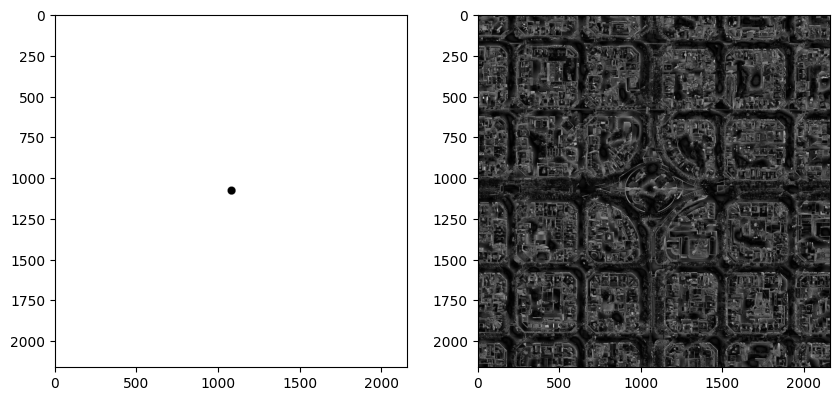

In [28]:
IHPF(image_edge,25)

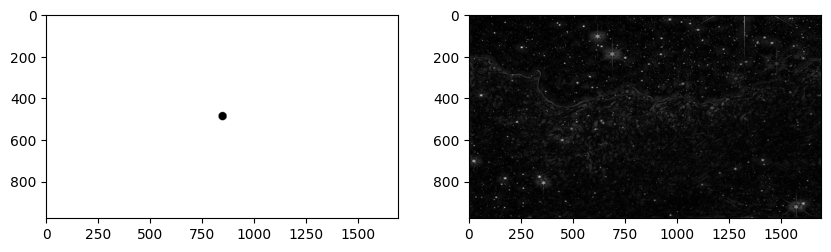

In [29]:
IHPF(img_smooth,20)

در اینجا به دلیل عبور فرکانس های بالا مقداری از کلیت تصویر یعنی ساختمان ها و غیره حذف شده و فقط لبه های تیز استخراج شده البته این موضوع در حالت دوم یعنی شعاع 80 ملموس تر خواهد بود 

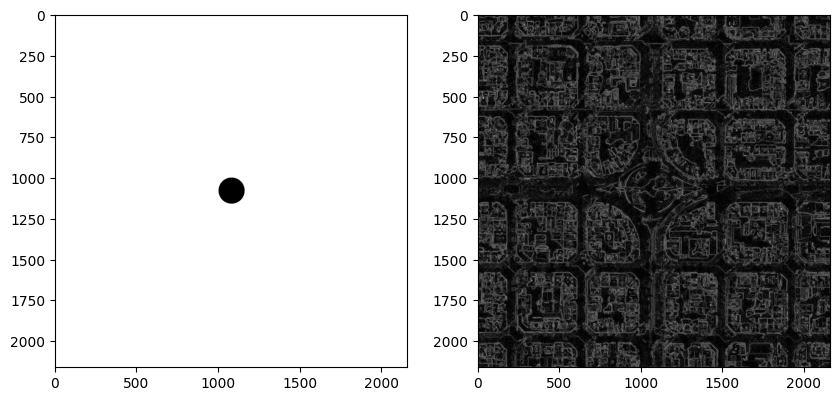

In [13]:
IHPF(img_smooth,80)

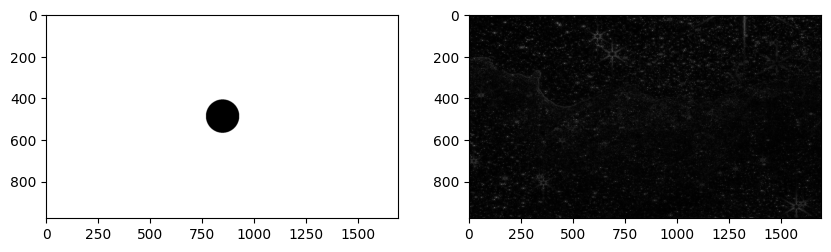

In [30]:
IHPF(img_smooth,80)

gussian high pass filter 

الگوریتم نوشتن این دو فیلتر همانند قبلی است فقط باید نوع دیتا ها فلوت32 انتخاب شود و فرمول نیز تغییر پیداکند ... از فرمول درون جزوه استفاده شده است 

In [65]:
def gaussian_highpass(image, D0, plot=True):

    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)
    

    magnitude_spectrum = np.log(np.abs(fshift) + 1)
    
    
    row, col = image.shape[0], image.shape[1]
    mask = np.zeros((row, col), dtype=np.float32) 
    for i in range(row):
        for j in range(col):
            D = np.sqrt((i - row/2)**2 + (j - col/2)**2)
            mask[i, j] = 1- (np.exp(-D**2 / (2 * D0**2)))
    

    filtered_image = fshift * mask
    
    
    img_back = np.fft.ifft2(np.fft.ifftshift(filtered_image))
    img_back = np.abs(img_back)
    
    
    
    plt.figure(figsize=(12, 6))
    plt.subplot(121), plt.imshow(mask, cmap='gray'), 
    plt.subplot(122), plt.imshow(img_back, cmap='gray'), plt.title('Filtered Image')
    plt.show()
    

فیلتر گوسین پایین گذر یک فیلتر با خشونت کم نسبت به قطع کردن فرکانس ها می باشد و همانطور که مشاهده می شود بر خلاف فیلتر ایده آل بسیار ارام تر تصاویر را شارپ می کند . 

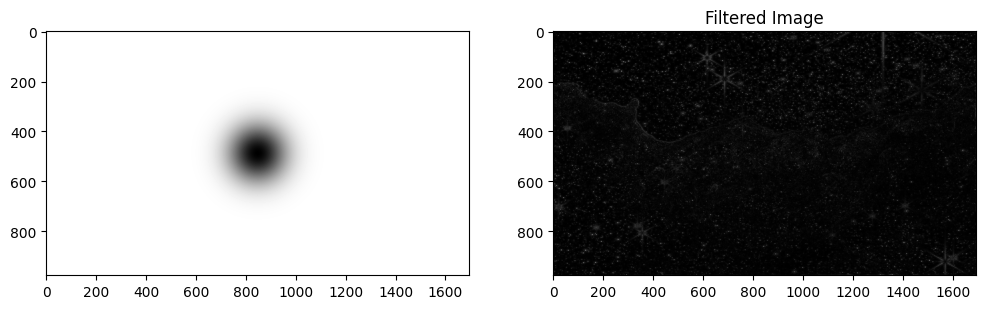

In [66]:
gaussian_highpass(img_smooth,80)

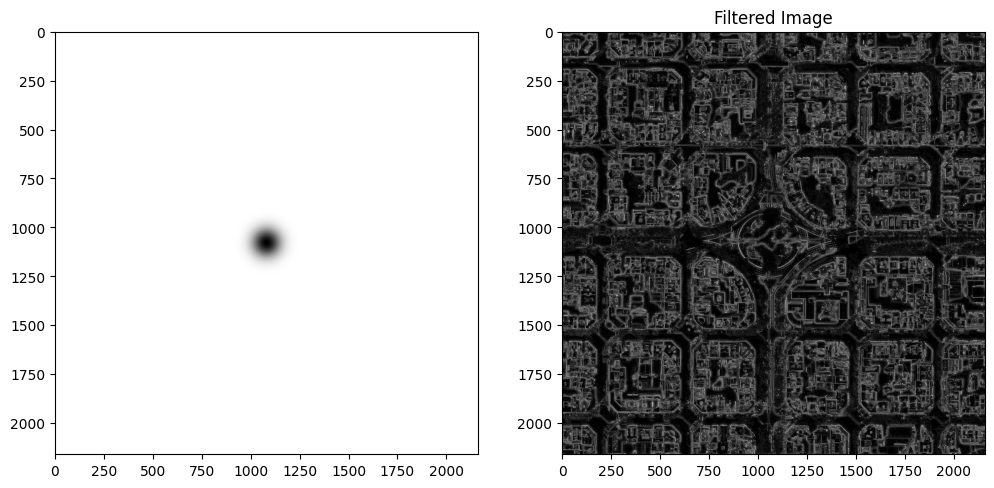

In [69]:
gaussian_highpass(image_edge,50)

GUSSIAN  low pass 

In [67]:

def gaussian_lowpass(image, D0, plot=True):

    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)
    

    magnitude_spectrum = np.log(np.abs(fshift) + 1)
    
    
    row, col = image.shape[0], image.shape[1]
    mask = np.zeros((row, col), dtype=np.float32)
    for i in range(row):
        for j in range(col):
            D = np.sqrt((i - row/2)**2 + (j - col/2)**2)
            mask[i, j] = np.exp(-D**2 / (2 * D0**2))
    

    filtered_image = fshift * mask
    
    
    img_back = np.fft.ifft2(np.fft.ifftshift(filtered_image))
    img_back = np.abs(img_back)
    
    
    
    plt.figure(figsize=(12, 6))
    plt.subplot(121), plt.imshow(mask, cmap='gray'), 
    plt.subplot(122), plt.imshow(img_back, cmap='gray'), plt.title('Filtered Image')
    plt.show()
    
    

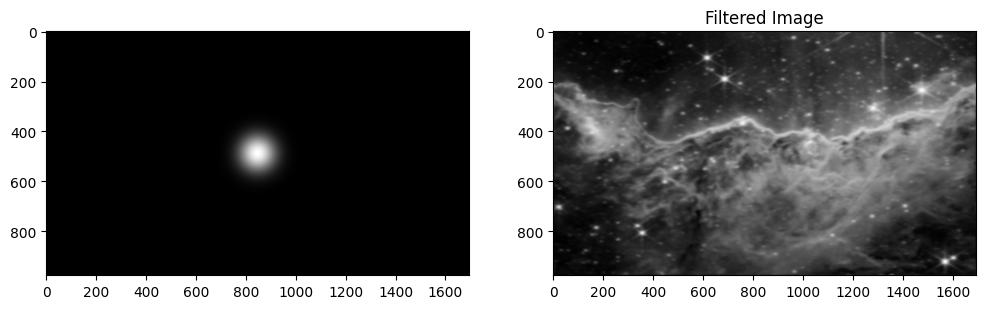

In [68]:
gaussian_lowpass(img_smooth,50)

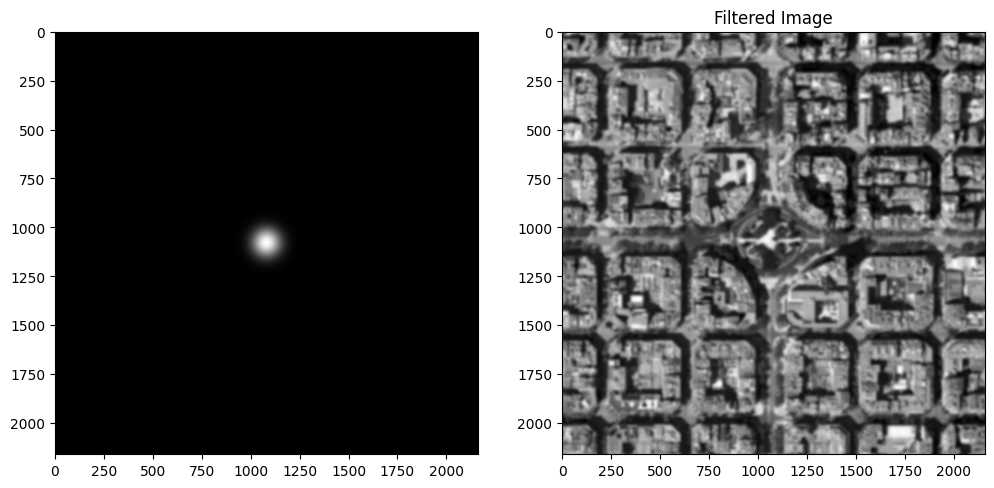

In [70]:
gaussian_lowpass(image_edge,50)

BHPF 

In [71]:
def BHPF(image, D0,n, plot=True):

    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)
    

    magnitude_spectrum = np.log(np.abs(fshift) + 1)
    
    
    row, col = image.shape[0], image.shape[1]
    mask = np.zeros((row, col), dtype=np.float32) 
    for i in range(row):
        for j in range(col):
            D = np.sqrt((i - row/2)**2 + (j - col/2)**2)
            mask[i, j] = 1 / (1+ (D0/D)**(2*n) )
    

    filtered_image = fshift * mask
    
    
    img_back = np.fft.ifft2(np.fft.ifftshift(filtered_image))
    img_back = np.abs(img_back)
    
    
    
    plt.figure(figsize=(12, 6))
    plt.subplot(121), plt.imshow(mask, cmap='gray'), 
    plt.subplot(122), plt.imshow(img_back, cmap='gray'), plt.title('Filtered Image')
    plt.show()
    

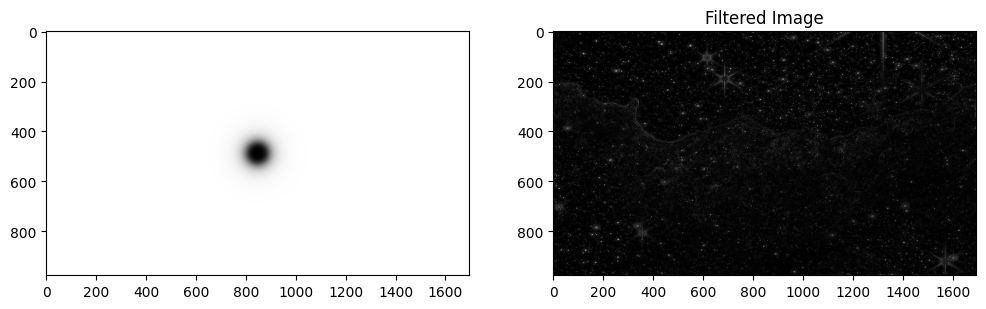

In [72]:
BHPF(img_smooth,50,2)

C:\Users\persian\AppData\Local\Temp\ipykernel_7128\3435863981.py:15: RuntimeWarning: divide by zero encountered in scalar divide
  mask[i, j] = 1 / (1+ (D0/D)**(2*n) )


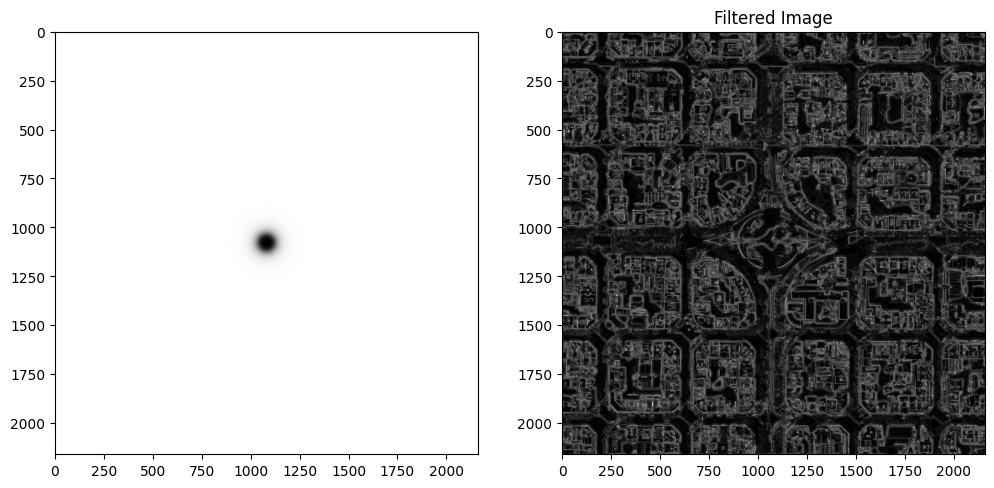

In [73]:
BHPF(image_edge,50,2)

In [74]:
def BLPF(image, D0,n, plot=True):

    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)
    

    magnitude_spectrum = np.log(np.abs(fshift) + 1)
    
    
    row, col = image.shape[0], image.shape[1]
    mask = np.zeros((row, col), dtype=np.float32) 
    for i in range(row):
        for j in range(col):
            D = np.sqrt((i - row/2)**2 + (j - col/2)**2)
            mask[i, j] = 1 / (1+ (D/D0)**(2*n) )
    

    filtered_image = fshift * mask
    
    
    img_back = np.fft.ifft2(np.fft.ifftshift(filtered_image))
    img_back = np.abs(img_back)
    
    
    
    plt.figure(figsize=(12, 6))
    plt.subplot(121), plt.imshow(mask, cmap='gray'), 
    plt.subplot(122), plt.imshow(img_back, cmap='gray'), plt.title('Filtered Image')
    plt.show()
    

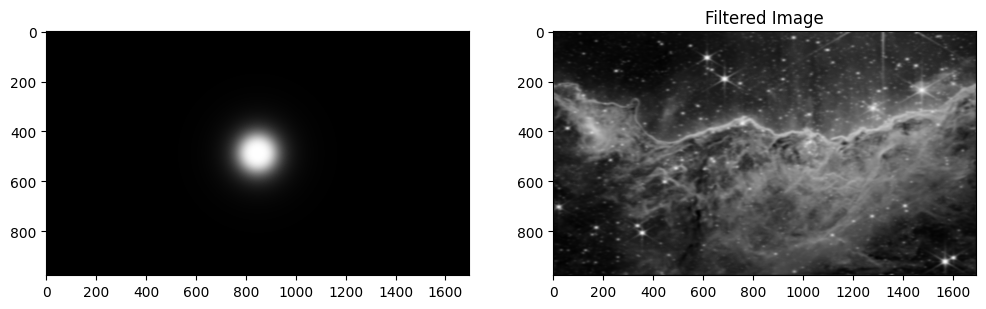

In [75]:
BLPF(img_smooth,80,2)

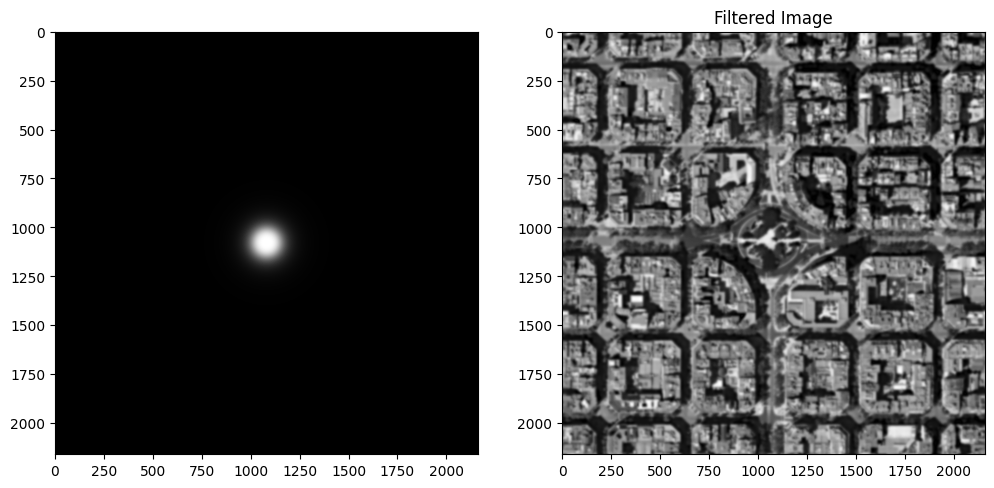

In [76]:
BLPF(image_edge,80,2)

همانطور که مشاهد شد در فیلتر باترورث قطع فرکانس ها با خشونت بیشتری نسبت به گوسین انجام میگیرد ... در اعمال این فیلتر ها نیاز به پارامتر مرتبه نیز هستیم که در تابع تعریف شده است . 